In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import pearsonr, spearmanr, skew, kurtosis
# Set aesthetic styling for the plots
sns.set_theme(style="whitegrid")

In [30]:
# Change to desatirized for the other direction
file_path = '../data/silver-gemini/scored_desatirized_headlines.json'

with open(file_path, 'r') as f:
    data = json.load(f)

print(f"Loaded {len(data)} original headlines.")

# Flatten the data structure
rows = []
for entry in data:
    original = entry.get('original_headline', '')
    candidates = entry.get('candidates', [])
    
    for cand in candidates:
        rows.append({
            'original_headline': original,
            'candidate_text': cand.get('text', ''),
            'content_score': cand.get('content_score', None),
            'style_score': cand.get('style_score', None)
        })

df = pd.DataFrame(rows)

# Drop any rows where scores might be missing
df = df.dropna(subset=['content_score', 'style_score'])

print(f"Total candidate headlines for analysis: {len(df)}")
display(df.head())

Loaded 13628 original headlines.
Total candidate headlines for analysis: 68130


,original_headline,candidate_text,content_score,style_score
0,leading probability researchers confounded by ...,Probability researchers report unusual coincid...,0.285674,0.126465
1,leading probability researchers confounded by ...,Three coworkers observed wearing identical shi...,0.579111,0.065430
2,leading probability researchers confounded by ...,Researchers studying probability encounter une...,0.277503,0.300781
3,leading probability researchers confounded by ...,Statistical anomaly observed: three colleagues...,0.417081,0.299316
4,leading probability researchers confounded by ...,Probability researchers investigate coincidenc...,0.311546,0.178711


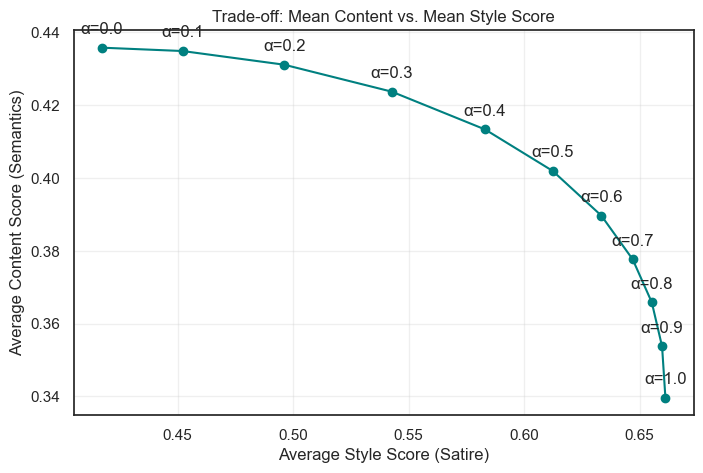

<Figure size 1000x600 with 0 Axes>

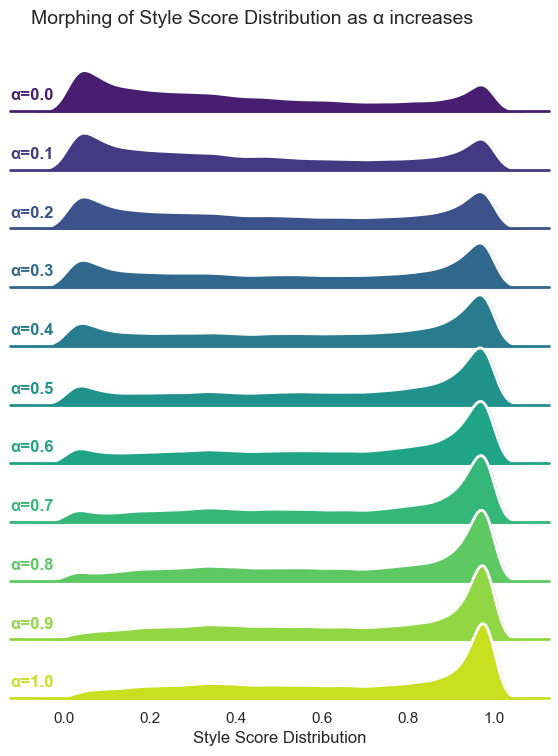

Higher-Order Moments of Selected Headlines:


,alpha,style_skewness,style_kurtosis
0,0.0,0.463627,-1.160665
1,0.1,0.293811,-1.352850
2,0.2,0.090436,-1.465867
3,0.3,-0.123272,-1.468667
4,0.4,-0.306445,-1.367556
5,0.5,-0.430612,-1.239696
6,0.6,-0.497288,-1.147621
7,0.7,-0.522805,-1.104113
8,0.8,-0.515622,-1.112001
9,0.9,-0.504422,-1.134595


In [31]:
# 1. Setup Simulation Parameters
alphas = np.linspace(0, 1, 11)  # 0.0, 0.1, ..., 1.0
results = []
distribution_data = []

for col in ['content_score', 'style_score']:
    df[f'{col}_norm'] = (df[col] - df[col].mean()) / df[col].std()


# 2. Iterate through Alpha values to select "Max" candidates
for alpha in alphas:
    # Calculate the convex combination score
    # S = alpha * Style + (1 - alpha) * Content
    df['combined_score'] = (alpha * df['style_score_norm']) + ((1 - alpha) * df['content_score_norm'])
    
    # Select the candidate with the highest combined score for each original headline
    # Note: df should be the flattened dataframe containing ALL candidates per headline
    idx = df.groupby('original_headline')['combined_score'].idxmax()
    winners = df.loc[idx].copy()
    
    # Calculate higher-order moments for the winners
    s_skew = skew(winners['style_score'])
    s_kurt = kurtosis(winners['style_score']) # Excess kurtosis
    
    results.append({
        'alpha': round(alpha, 2),
        'mean_content': winners['content_score'].mean(),
        'mean_style': winners['style_score'].mean(),
        'style_skewness': s_skew,
        'style_kurtosis': s_kurt
    })
    
    # Collect distribution data for plotting
    winners['alpha_label'] = f"α={alpha:.1f}"
    distribution_data.append(winners)

results_df = pd.DataFrame(results)
full_dist_df = pd.concat(distribution_data)

# 3. Visualization: The Pareto Trade-off Curve
plt.figure(figsize=(8, 5))
plt.plot(results_df['mean_style'], results_df['mean_content'], marker='o', linestyle='-', color='teal')
for i, txt in enumerate(results_df['alpha']):
    plt.annotate(f"α={txt}", (results_df['mean_style'][i], results_df['mean_content'][i]), textcoords="offset points", xytext=(0,10), ha='center')

plt.title('Trade-off: Mean Content vs. Mean Style Score')
plt.xlabel('Average Style Score (Satire)')
plt.ylabel('Average Content Score (Semantics)')
plt.grid(True, alpha=0.3)
plt.show()

# 4. Visualization: Ridgeline Plot (Distribution Morphing)
plt.figure(figsize=(10, 6))
sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

# Using FacetGrid to create the "Ridge" effect
g = sns.FacetGrid(full_dist_df, row="alpha_label", hue="alpha_label", aspect=9, height=0.7, palette="viridis")
g.map(sns.kdeplot, "style_score", bw_adjust=.5, clip_on=False, fill=True, alpha=1, linewidth=1.5)
g.map(sns.kdeplot, "style_score", clip_on=False, color="w", lw=2, bw_adjust=.5)
g.map(plt.axhline, y=0, lw=2, clip_on=False)

# Define and use a simple function to label the plot in axes coordinates
def label(x, color, label):
    ax = plt.gca()
    ax.text(0, .2, label, fontweight="bold", color=color,
            ha="left", va="center", transform=ax.transAxes)

g.map(label, "style_score")
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)
plt.subplots_adjust(hspace=-.25)
g.set_xlabels("Style Score Distribution")
plt.suptitle("Morphing of Style Score Distribution as α increases", fontsize=14)
plt.show()

# 5. Display Statistical Moments Table
print("Higher-Order Moments of Selected Headlines:")
display(results_df[['alpha', 'style_skewness', 'style_kurtosis']])

,content_score,style_score
count,74364.000000,74364.000000
mean,0.266285,0.397104
std,0.145592,0.340459
min,-0.313808,0.002768
25%,0.165360,0.040894
50%,0.263933,0.354248
75%,0.364652,0.718750
max,0.831147,0.992188


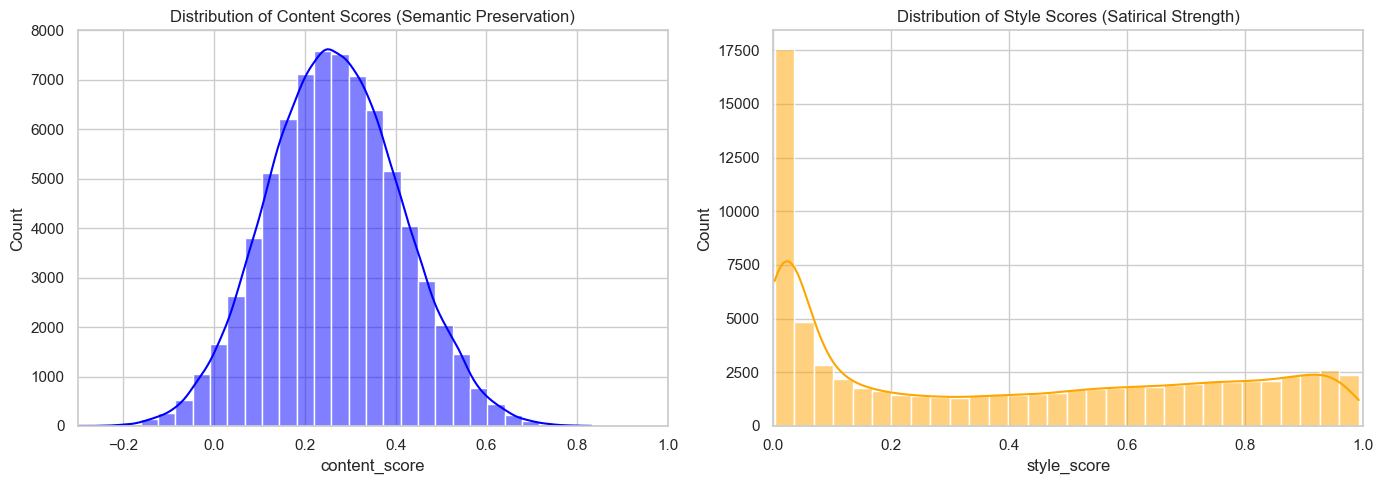

In [19]:
# Display summary statistics for the scores
display(df[['content_score', 'style_score']].describe())

# Plot the individual distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['content_score'], bins=30, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribution of Content Scores (Semantic Preservation)')
axes[0].set_xlim(-0.3, 1)

sns.histplot(df['style_score'], bins=30, kde=True, ax=axes[1], color='orange')
axes[1].set_title('Distribution of Style Scores (Satirical Strength)')
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.show()

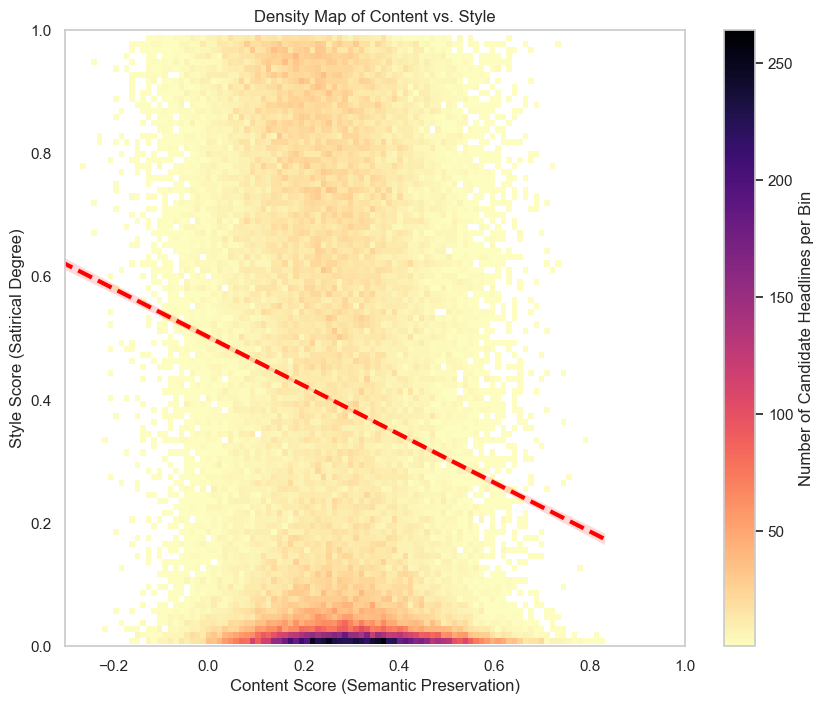

In [11]:
# Use a 2D histogram to efficiently map density for 200k points
plt.figure(figsize=(10, 8))

# bins=100 creates a 100x100 grid. cmin=1 makes completely empty bins transparent.
h = plt.hist2d(
    df['content_score'], 
    df['style_score'], 
    bins=100, 
    cmap='magma_r', # A good colormap for density
    cmin=1 
)
sns.regplot(
    data=df, 
    x='content_score', 
    y='style_score', 
    scatter=False, 
    color='red', 
    line_kws={'linewidth': 3, 'linestyle': '--'},
    label='Linear Regression Trend'
)
# Add a colorbar to show the scale of the point counts
plt.colorbar(h[3], label='Number of Candidate Headlines per Bin')

plt.title('Density Map of Content vs. Style')
plt.xlabel('Content Score (Semantic Preservation)')
plt.ylabel('Style Score (Satirical Degree)')
plt.xlim(-0.3, 1)
plt.ylim(0, 1)
plt.grid(False) # Turn off gridlines for cleaner density map
plt.show()

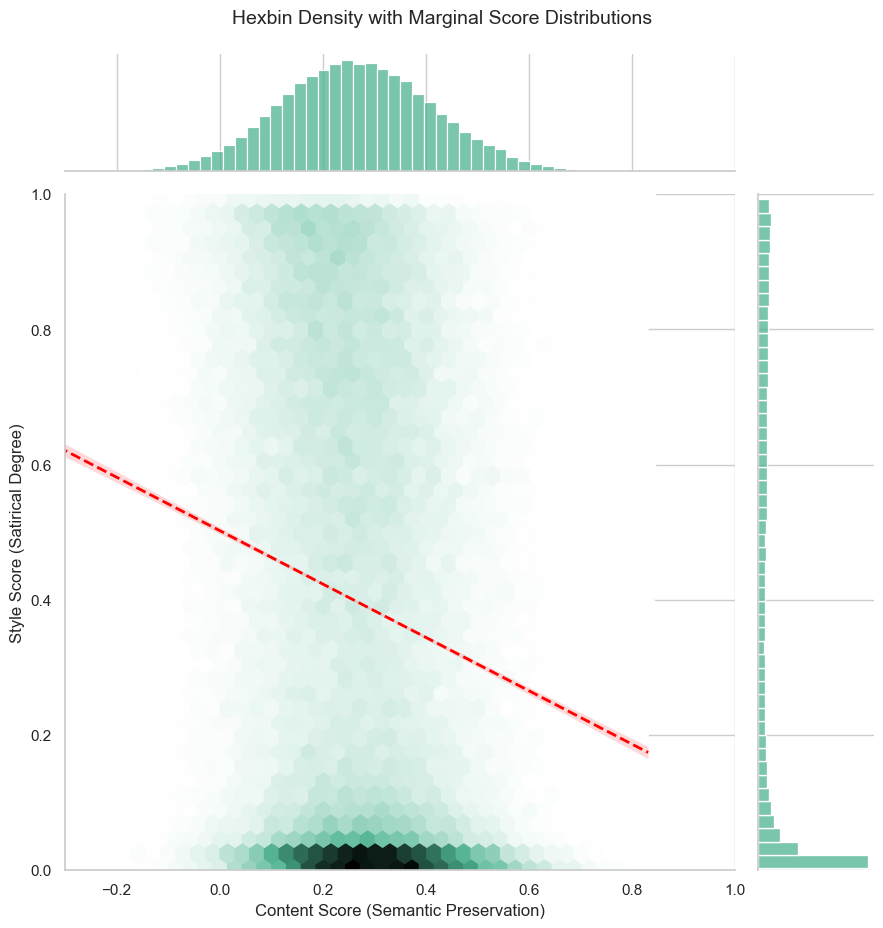

In [12]:
# Create a hexbin jointplot
g = sns.jointplot(
    data=df, 
    x='content_score', 
    y='style_score', 
    kind="hex", 
    color="#4CB391",
    gridsize=40, # Number of hexagons in the x-direction
    xlim=(-0.3, 1),
    ylim=(0, 1),
    height=9,
    marginal_kws=dict(bins=50, fill=True) # More bins for the side histograms
)

sns.regplot(
    data=df, 
    x='content_score', 
    y='style_score', 
    scatter=False, # Turn off points, we only want the line
    ax=g.ax_joint, # Target the central hexbin plot
    line_kws={'color': 'red', 'linewidth': 2, 'linestyle': '--'}
)

g.figure.suptitle('Hexbin Density with Marginal Score Distributions', y=1.03, fontsize=14)
g.set_axis_labels('Content Score (Semantic Preservation)', 'Style Score (Satirical Degree)')
plt.show()

In [13]:
# Calculate correlation coefficients
pearson_corr, p_value_p = pearsonr(df['content_score'], df['style_score'])
spearman_corr, p_value_s = spearmanr(df['content_score'], df['style_score'])

print(f"Pearson Correlation:  {pearson_corr:.4f} (p-value: {p_value_p:.4e})")
print(f"Spearman Correlation: {spearman_corr:.4f} (p-value: {p_value_s:.4e})")

slope, intercept = np.polyfit(df['content_score'], df['style_score'], 1)

# Format the equation string for the legend and printout
equation_str = f"y = {slope:.4f}x + {intercept:.4f}"

print(f"Regression Line Equation: {equation_str}")

if pearson_corr < -0.3:
    print("\nConclusion: There is a notable trade-off. As headlines become more satirical, they lose their original semantic meaning.")
elif pearson_corr > 0.3:
    print("\nConclusion: Unexpected result. The model seems to increase satire while better preserving semantics.")
else:
    print("\nConclusion: The relationship is weak or non-existent. The model's satire generation might be largely independent of semantic preservation.")

Pearson Correlation:  -0.1688 (p-value: 0.0000e+00)
Spearman Correlation: -0.1711 (p-value: 0.0000e+00)
Regression Line Equation: y = -0.3948x + 0.5022

Conclusion: The relationship is weak or non-existent. The model's satire generation might be largely independent of semantic preservation.
